# Sprint 4 — v11: worst-group optimisation

**Project:** Q-INTERVAL-Lite+ · **Author:** Pasindu Pahasara (104348348)

## Multi-task is closed. Two runs, both worse.

| Model | case-weighted slope | pooled recall (50 cases) | macro F1 | Benign F1 |
|---|---|---|---|---|
| v8 effnetv2 (no source) — baseline | **0.650** | 0.380 | 0.7152 | 0.5851 |
| v9 density + abnormality | 0.815 | 0.460 | 0.7124 | 0.5754 |
| v10 density only | **1.045** | 0.360 | 0.7168 | **0.6059** |

Dropping the confounded abnormality head made the shortcut *worse*, not better. That kills the
hypothesis rather than refining it.

**Why it backfires — and it is not the missingness pattern the v9 mitigation guarded against.**
CMMD carries **zero** density labels. The density head's own uncertainty is therefore a source
detector: "I cannot predict density here" implies CMMD implies a 79.7% malignant prior.
`BALANCE_AUX_BY_SOURCE` cannot touch that, because the signal lives in which images the head
was never trained on. The label *values* are confounded with provenance, not merely their
availability.

The reliable numbers show it plainly: v10 pushed CMMD malignant recall to 0.9316 (613/658)
while DDSM fell to 0.4635 (254/548). That is 1,206 cases saying the model follows the dataset
prior harder than before.

One thing worth keeping: **density supervision helped the Benign boundary.** Benign F1 0.6059
is the best of any single no-source model, and macro AUC 0.8801 likewise. The auxiliary label
is useful for the class boundary and harmful for provenance-independence at the same time.

## The selection criterion threw away the best checkpoint

| Epoch | macro F1 | slope | `balanced` | `slope_penalised` |
|---|---|---|---|---|
| 4 (saved) | 0.6988 | 1.040 | **0.6065** | 0.4387 |
| 9 (lost) | 0.6905 | **0.492** | 0.5595 | **0.5676** |

`balanced` saved epoch 4. `slope_penalised` would have saved epoch 9 — selection slope
**0.492**, better than the v8 EfficientNetV2 baseline, for 0.8 points of macro F1. On the
selection set, pooled recall and slope correlate at **−0.50**, so `balanced` cannot steer the
slope even in principle. Epoch 9 was never written to disk.

## What this notebook fixes

- **`SELECT_ON = 'slope_penalised'` by default** — the only criterion that tracks the quantity
  being optimised.
- **Every criterion gets its own checkpoint.** One run now yields four candidate models
  (`macro_f1`, `lowprev_recall`, `balanced`, `slope_penalised`) instead of one, so a good epoch
  can never be discarded because the scoring rule disagreed with it.
- **Early stopping follows `SELECT_ON`**, so patience cannot fire while the selected metric is
  still improving — which is what happened at epoch 10 of v10.

## The experiment: Group DRO

Auxiliary heads are off. The primary loss becomes **worst-group risk** over source × class
groups (Sagawa et al., 2020), with group weights updated by exponentiated gradient ascent.

The reason this is the clean test: DRO uses source only to *partition the loss*. It never
enters the representation and never depends on which labels exist, so it cannot be confounded
the way the auxiliary heads were.

**Bar to beat: v8 ResNet-101, case-weighted slope 0.440**, measured across 1,257 malignant
cases. Everything else sits at 0.650 or worse.

Watch `q_max` in the epoch log. Above 0.6 the model is training on a single group and
`DRO_ETA` needs lowering.

## 1. Configuration

In [ ]:
# ---------------- CONFIG ----------------
ARCH        = 'effnetv2'     # 'effnetv2' (v6 recipe, 384px) | 'resnet101' (512px)
USE_SOURCE  = False          # never an input again - v8 settled that

# ---- auxiliary heads (the experiment) ----
AUX_DENSITY = False; W_DENSITY = 0.3     # OFF. v10 showed density-only made the shortcut
                                         # worse (slope 0.650 -> 1.045), because CMMD has no
                                         # density labels at all, so the head's uncertainty
                                         # is itself a CMMD detector. Turn on only if you
                                         # want the Benign F1 gain (0.5851 -> 0.6059) and
                                         # accept the slope cost.
AUX_ABNORM  = False; W_ABNORM  = 0.3     # 30.5% coverage but all of it is CMMD+DMID, and in
                                         # v9 it reached only 0.6371 against a 0.5982 majority
                                         # baseline. Maximum confounding, minimum signal. Off.
AUX_BIRADS  = False; W_BIRADS  = 0.2     # 16.6% coverage, same confounding problem. Off.

BALANCE_AUX_BY_SOURCE = True   # average aux loss over sources, not samples.
                               # Without this the abnormality head is trained
                               # almost entirely on CMMD.

# ---- experiment 2: worst-group optimisation ----
GROUP_DRO   = True           # THE EXPERIMENT. Minimise worst (source x class) group loss.
                             # Source is used only to partition the loss - it never enters
                             # the representation, so unlike the auxiliary heads this cannot
                             # be confounded by which labels happen to exist.
DRO_ETA     = 0.0001         # step size for the group-weight ascent.
                             # Tuned by simulation over 435 steps/epoch x 25 epochs:
                             #   0.01   -> q collapses onto ONE group inside 1 epoch
                             #   0.001  -> collapses by epoch 25
                             #   0.0001 -> worst group up-weighted ~3.4x, 13 of 15
                             #             groups still contributing at epoch 25
                             # Watch q_max in the epoch log; if it approaches 1.0 the
                             # model is training on a single group and eta is too high.

LOSS_TYPE   = 'ce'           # 'ce' | 'focal' | 'lmf'   (primary head)
USE_SAMPLER = True

# Checkpoint selection.
#   macro_f1        - aggregate only
#   lowprev_recall  - pooled malignant recall on the low-prevalence sources
#   balanced        - 0.5 * macro_f1 + 0.5 * lowprev_recall        <- default
#   slope_penalised - macro_f1 - SLOPE_PENALTY * abs(shortcut slope)
SELECT_ON     = 'slope_penalised'   # v10 lesson: 'balanced' saved epoch 4 (slope 1.040) while
                                    # epoch 9 (slope 0.492) scored higher under this rule and
                                    # was lost. On the selection set, pooled recall and slope
                                    # correlate at -0.50, so 'balanced' cannot steer the slope.
SLOPE_PENALTY = 0.25

# Save the best checkpoint under EVERY criterion, not just SELECT_ON. One run then yields
# four candidate models and no good epoch is discarded because the scoring rule disagreed.
SAVE_ALL_CRITERIA = True

# A source counts as screening-like below this malignant rate. 0.30 pools DMID, INbreast
# and KAU-BCMD: 35 malignant cases in the selection set and 50 in test, against 10 and 14
# for KAU-BCMD alone.
LOWPREV_MAX_PRIOR = 0.30

# Reporting only. v9 showed a single-source recall on 14 cases moves in 7.14-point steps,
# so it must never drive checkpoint selection again.
MIN_MAL_FOR_SELECTION = 20

EPOCHS   = 25
PATIENCE = 6
LR       = 1e-4
WD       = 1e-4

FOCAL_GAMMA = 2.0
LDAM_MAX_M, LDAM_S = 0.5, 30
LMF_ALPHA, LMF_BETA = 1.0, 1.0
DRW_START_EPOCH = None
# ----------------------------------------

_aux = ''.join([('d' if AUX_DENSITY else ''), ('a' if AUX_ABNORM else ''),
                ('b' if AUX_BIRADS else '')]) or 'none'
TAG = f"v9_{ARCH}_mt-{_aux}{'_dro' if GROUP_DRO else ''}_{LOSS_TYPE}"
print('Experiment:', TAG)
print('Auxiliary heads:', {'density': AUX_DENSITY, 'abnormality': AUX_ABNORM, 'birads': AUX_BIRADS})
print('Group DRO:', GROUP_DRO, '| selection:', SELECT_ON)

Experiment: v9_effnetv2_mt-none_dro_ce
Auxiliary heads: {'density': False, 'abnormality': False, 'birads': False}
Group DRO: True | selection: slope_penalised


## 2. Setup

In [ ]:
!pip install -q albumentations scikit-learn tqdm matplotlib seaborn

import os, time, json, random
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.models import (resnet101, ResNet101_Weights,
                                efficientnet_v2_s, EfficientNet_V2_S_Weights)
import cv2, albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (accuracy_score, f1_score, recall_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix, classification_report)
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
CLASS_NAMES = ['Normal', 'Benign', 'Malignant']
MAL = 2
IGNORE = -100          # torch's cross_entropy ignore_index - how missing aux labels are masked
print('Device:', device)

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT  = '/content/drive/MyDrive/momobench-dataset'
EXTRACT_DIR = '/content/dataset_original'
CHECKPT_DIR = os.path.join(DRIVE_ROOT, f'checkpoints_{TAG}')
SPLIT_PATH  = os.path.join(DRIVE_ROOT, 'sprint4_audit', 'frozen_split.json')
os.makedirs(CHECKPT_DIR, exist_ok=True)

if not os.path.isdir(os.path.join(EXTRACT_DIR, 'dataset')):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    os.system(f'unzip -q "{DRIVE_ROOT}/dataset.zip" -d "{EXTRACT_DIR}"')
    print('extracted')
else:
    print('already extracted')

IMG_ROOT  = os.path.join(EXTRACT_DIR, 'dataset')
META_PATH = os.path.join(IMG_ROOT, 'metadata.csv')
print('frozen split available:', os.path.exists(SPLIT_PATH))

Mounted at /content/drive
extracted
frozen split available: True


## 3. Data — same frozen split, plus three auxiliary label columns

Test set is byte-identical to every other Sprint 4 run. Missing auxiliary labels are encoded
as `IGNORE = -100` so `F.cross_entropy` drops them without any masking arithmetic on my side.

In [ ]:
df = pd.read_csv(META_PATH)
df['classification'] = df['classification'].replace({'Suspicious Malignant': 'Malignant'})
df = df[df['source_dataset'] != 'cdd-cesm'].reset_index(drop=True)
df['image_path'] = df['preprocessed_image_path'].apply(lambda r: os.path.join(IMG_ROOT, r))
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)
df['label'] = df['classification'].map({c: i for i, c in enumerate(CLASS_NAMES)})

# ---- clinical covariates available at inference ----
def age_bucket(a):
    if pd.isna(a): return 7
    for i, hi in enumerate([30, 40, 50, 60, 70, 80]):
        if a < hi: return i
    return 6
df['age_idx']  = df['subject_age'].apply(age_bucket); N_AGE = 8
df['view_idx'] = df['view'].map({'CC': 0, 'MLO': 1}).fillna(2).astype(int); N_VIEW = 3
df['lat_idx']  = df['laterality'].map({'L': 0, 'R': 1}).astype(int); N_LAT = 2
SOURCE_NAMES = sorted(df['source_dataset'].unique()); N_SRC = len(SOURCE_NAMES)
df['src_idx'] = df['source_dataset'].map({s: i for i, s in enumerate(SOURCE_NAMES)})

# ---- auxiliary targets, IGNORE where absent ----
DENSITY_NAMES = ['A', 'B', 'C', 'D']; N_DENSITY = 4
df['den_idx'] = df['density'].map({d: i for i, d in enumerate(DENSITY_NAMES)}).fillna(IGNORE).astype(int)

# BI-RADS 1-5 only. 0 = incomplete assessment, 6 = biopsy-proven - both excluded
# for the same reason they were excluded from the standalone BI-RADS model in Sprint 2.
N_BIRADS = 5
df['bir_idx'] = df['BIRADS'].apply(lambda b: int(b) - 1 if pd.notna(b) and 1 <= b <= 5 else IGNORE).astype(int)

# 'others' (10 rows) dropped rather than given a class of its own
ABNORM_NAMES = ['normal', 'mass', 'calcification', 'both']; N_ABNORM = 4
df['abn_idx'] = df['abnormality'].map({a: i for i, a in enumerate(ABNORM_NAMES)}).fillna(IGNORE).astype(int)

if os.path.exists(SPLIT_PATH):
    sp = json.load(open(SPLIT_PATH))
    train_ids = set(sp['train']) | set(sp['validation'])
    sel_ids   = set(sp['selection'])
    test_ids  = set(sp['test'])
    print('Using frozen split from the audit.')
else:
    raise FileNotFoundError('Run Sprint4_Step1_Audit.ipynb first to create frozen_split.json')

train_df = df[df['source_subjectID'].isin(train_ids)].reset_index(drop=True)
sel_df   = df[df['source_subjectID'].isin(sel_ids)].reset_index(drop=True)
test_df  = df[df['source_subjectID'].isin(test_ids)].reset_index(drop=True)

CLS_NUM_LIST = train_df['label'].value_counts().sort_index().to_numpy()
print(f'train     {len(train_df):5d} images  ({train_df.source_subjectID.nunique()} patients)')
print(f'selection {len(sel_df):5d} images  ({sel_df.source_subjectID.nunique()} patients)')
print(f'test      {len(test_df):5d} images  ({test_df.source_subjectID.nunique()} patients)  FROZEN')
print(f'train class counts: {dict(zip(CLASS_NAMES, CLS_NUM_LIST))}')

print('\nAUXILIARY LABEL COVERAGE IN TRAIN')
for name, col, n_cls in [('density', 'den_idx', N_DENSITY),
                         ('abnormality', 'abn_idx', N_ABNORM),
                         ('birads', 'bir_idx', N_BIRADS)]:
    have = (train_df[col] != IGNORE)
    by_src = train_df[have].groupby('source_dataset').size().to_dict()
    print(f'  {name:12s} {have.sum():6d} / {len(train_df)}  ({100*have.mean():5.1f}%)   {by_src}')

Using frozen split from the audit.
train     13917 images  (4122 patients)
selection  1990 images  (581 patients)
test       2821 images  (831 patients)  FROZEN
train class counts: {'Normal': np.int64(3642), 'Benign': np.int64(4276), 'Malignant': np.int64(5999)}

AUXILIARY LABEL COVERAGE IN TRAIN
  density       10064 / 13917  ( 72.3%)   {'ddsm': 7752, 'dmid': 379, 'inbreast': 305, 'kau-bcmd': 1628}
  abnormality    4219 / 13917  ( 30.3%)   {'cmmd': 3846, 'dmid': 373}
  birads         2293 / 13917  ( 16.5%)   {'dmid': 364, 'inbreast': 301, 'kau-bcmd': 1628}


### 3a. Confounding check — how much source does the missingness pattern carry?

This is the number that decides whether the mitigation is needed or merely tidy. If knowing
*which auxiliary labels are present* predicts source almost perfectly, then an unbalanced
auxiliary loss is a provenance signal with extra steps.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pattern = np.stack([(train_df['den_idx'] != IGNORE).to_numpy().astype(int),
                    (train_df['abn_idx'] != IGNORE).to_numpy().astype(int),
                    (train_df['bir_idx'] != IGNORE).to_numpy().astype(int)], 1)
acc = cross_val_score(LogisticRegression(max_iter=1000), pattern,
                      train_df['src_idx'].to_numpy(), cv=3, scoring='accuracy').mean()
print(f'Predicting SOURCE from the label-presence pattern alone: {acc:.4f} accuracy')
print(f'(chance = {1.0/N_SRC:.4f}, majority class = {train_df["src_idx"].value_counts(normalize=True).max():.4f})')
print()
print(pd.crosstab(train_df['source_dataset'],
                  [pattern[:, 0], pattern[:, 1], pattern[:, 2]]).to_string())
print('\nIf this is near-perfect, BALANCE_AUX_BY_SOURCE is doing real work, not cosmetics.')

Predicting SOURCE from the label-presence pattern alone: 0.9770 accuracy
(chance = 0.2000, majority class = 0.5573)

col_0           0                 1               
col_1           0        1        0         1     
col_2           0  1     0  1     0     1   0    1
source_dataset                                    
cmmd            0  0  3846  0     0     0   0    0
ddsm            4  0     0  0  7752     0   0    0
dmid            0  0     0  2     0     8  17  354
inbreast        0  1     0  0     5   300   0    0
kau-bcmd        0  0     0  0     0  1628   0    0

If this is near-perfect, BALANCE_AUX_BY_SOURCE is doing real work, not cosmetics.


## 4. Augmentation and loaders

In [ ]:
IMG_SIZE   = 512 if ARCH == 'resnet101' else 384
BATCH_SIZE = 16  if ARCH == 'resnet101' else 32
NORM_MEAN, NORM_STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.12, rotate_limit=18,
                       border_mode=cv2.BORDER_CONSTANT, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.18, contrast_limit=0.18, p=0.5),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD), ToTensorV2()])
eval_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
                     A.Normalize(mean=NORM_MEAN, std=NORM_STD), ToTensorV2()])


class MammoMTDS(Dataset):
    '''Source index is returned for grouping and reporting only.
    It is never fed to the model while USE_SOURCE is False.'''
    def __init__(self, d, transform):
        self.df = d.reset_index(drop=True); self.tf = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.cvtColor(cv2.imread(r['image_path']), cv2.COLOR_BGR2RGB)
        return (self.tf(image=img)['image'],
                int(r['age_idx']), int(r['view_idx']), int(r['lat_idx']), int(r['src_idx']),
                int(r['label']), int(r['den_idx']), int(r['abn_idx']), int(r['bir_idx']))


train_ds = MammoMTDS(train_df, train_tf)
sel_ds   = MammoMTDS(sel_df,   eval_tf)
test_ds  = MammoMTDS(test_df,  eval_tf)

if USE_SAMPLER:
    w  = 1.0 / CLS_NUM_LIST
    sw = train_df['label'].map(lambda c: w[c]).to_numpy()
    sampler = WeightedRandomSampler(torch.tensor(sw, dtype=torch.double), len(sw), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=2, pin_memory=True)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
sel_loader  = DataLoader(sel_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'{ARCH} @ {IMG_SIZE}px, batch {BATCH_SIZE}')

effnetv2 @ 384px, batch 32


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 5. Model — one backbone, four heads

The auxiliary heads are deliberately thin (a single linear layer on the pooled feature). The
point is to shape the **backbone**, not to build good density or BI-RADS classifiers — those
already exist as standalone models. A heavy auxiliary head would learn the task in the head
and leave the backbone unchanged, which is the failure mode to avoid.

Auxiliary heads read the pooled image feature only, not the metadata embeddings: density
predicted from an age embedding would be cheating.

In [ ]:
N_META = 4 if USE_SOURCE else 3

class CBAM(nn.Module):
    def __init__(self, c, r=16, k=7):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1); self.mx = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(nn.Conv2d(c, c//r, 1, bias=False), nn.ReLU(inplace=True),
                                 nn.Conv2d(c//r, c, 1, bias=False))
        self.sp = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        x = x * torch.sigmoid(self.mlp(self.avg(x)) + self.mlp(self.mx(x)))
        return x * torch.sigmoid(self.sp(torch.cat([x.mean(1, keepdim=True),
                                                    x.amax(1, keepdim=True)], 1)))


class MultiTaskNet(nn.Module):
    def __init__(self, arch='effnetv2', emb=16, dr=0.3):
        super().__init__()
        self.arch = arch
        if arch == 'resnet101':
            self.backbone = resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
            self.backbone.fc = nn.Identity(); feat_dim = 2048; self.cbam = None
        else:
            self.features = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1).features
            self.cbam = CBAM(1280); self.avgpool = nn.AdaptiveAvgPool2d(1); feat_dim = 1280
        self.feat_dim = feat_dim

        self.age_emb  = nn.Embedding(N_AGE,  emb)
        self.view_emb = nn.Embedding(N_VIEW, emb)
        self.lat_emb  = nn.Embedding(N_LAT,  emb)
        self.src_emb  = nn.Embedding(N_SRC,  emb) if USE_SOURCE else None

        # primary head sees image + clinical covariates
        self.classifier = nn.Sequential(
            nn.Dropout(dr), nn.Linear(feat_dim + N_META*emb, 256),
            nn.ReLU(inplace=True), nn.Dropout(dr), nn.Linear(256, 3))

        # auxiliary heads see the image feature only
        self.head_den = nn.Linear(feat_dim, N_DENSITY) if AUX_DENSITY else None
        self.head_abn = nn.Linear(feat_dim, N_ABNORM)  if AUX_ABNORM  else None
        self.head_bir = nn.Linear(feat_dim, N_BIRADS)  if AUX_BIRADS  else None

    def trunk(self, x):
        if self.arch == 'resnet101':
            return self.backbone(x)
        return self.avgpool(self.cbam(self.features(x))).flatten(1)

    def meta(self, a, v, l, s):
        parts = [self.age_emb(a), self.view_emb(v), self.lat_emb(l)]
        if self.src_emb is not None: parts.append(self.src_emb(s))
        return torch.cat(parts, 1)

    def forward(self, x, a, v, l, s):
        f = self.trunk(x)
        out = {'cls': self.classifier(torch.cat([f, self.meta(a, v, l, s)], 1))}
        if self.head_den is not None: out['den'] = self.head_den(f)
        if self.head_abn is not None: out['abn'] = self.head_abn(f)
        if self.head_bir is not None: out['bir'] = self.head_bir(f)
        return out


model = MultiTaskNet(ARCH).to(device)
n_heads = 1 + sum(h is not None for h in [model.head_den, model.head_abn, model.head_bir])
print(f'{ARCH}: {sum(p.numel() for p in model.parameters())/1e6:.2f}M params, {n_heads} heads')
print('source embedding present:', model.src_emb is not None)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 95.5MB/s]


effnetv2: 20.72M params, 1 heads
source embedding present: False


## 6. Losses

Three pieces:

1. **Primary loss** — unchanged from v8 (CE / Focal / LMF), so the comparison is clean.
2. **Auxiliary loss** — masked cross-entropy, optionally averaged over sources rather than
   samples so CMMD cannot dominate the abnormality head.
3. **Group DRO** — off by default. When on, the primary loss becomes the worst-group loss
   over source × class, with group weights updated by exponentiated gradient ascent.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__(); self.gamma = gamma; self.weight = weight
    def forward(self, x, t, reduction='mean'):
        w = self.weight.to(x.device) if self.weight is not None else None
        ce = F.cross_entropy(x, t, weight=w, reduction='none')
        l = (1 - torch.exp(-ce))**self.gamma * ce
        return l if reduction == 'none' else l.mean()

class LDAMLoss(nn.Module):
    def __init__(self, cls_num_list, max_m=0.5, s=30, weight=None):
        super().__init__()
        m = 1.0/np.sqrt(np.sqrt(np.asarray(cls_num_list, float))); m = m*(max_m/m.max())
        self.register_buffer('m_list', torch.tensor(m, dtype=torch.float32))
        self.s = s; self.weight = weight
    def forward(self, x, t, reduction='mean'):
        idx = torch.zeros_like(x, dtype=torch.bool); idx.scatter_(1, t.view(-1,1), True)
        out = torch.where(idx, x - self.m_list.to(x.device)[t].view(-1,1), x)
        w = self.weight.to(x.device) if self.weight is not None else None
        return F.cross_entropy(self.s*out, t, weight=w, reduction=reduction)

class LMFLoss(nn.Module):
    def __init__(self, cls_num_list, a=1.0, b=1.0, gamma=2.0, max_m=0.5, s=30, weight=None):
        super().__init__()
        self.f = FocalLoss(gamma, weight); self.l = LDAMLoss(cls_num_list, max_m, s, weight)
        self.a, self.b = a, b
    def forward(self, x, t, reduction='mean'):
        return self.a*self.f(x, t, reduction) + self.b*self.l(x, t, reduction)

class CELoss(nn.Module):
    def __init__(self, weight=None):
        super().__init__(); self.weight = weight
    def forward(self, x, t, reduction='mean'):
        w = self.weight.to(x.device) if self.weight is not None else None
        return F.cross_entropy(x, t, weight=w, reduction=reduction)

def build_criterion(kind, cls, weight=None):
    if kind == 'ce':    return CELoss(weight)
    if kind == 'focal': return FocalLoss(FOCAL_GAMMA, weight)
    if kind == 'lmf':   return LMFLoss(cls, LMF_ALPHA, LMF_BETA, FOCAL_GAMMA, LDAM_MAX_M, LDAM_S, weight)
    raise ValueError(kind)

def cb_weights(cls, beta=0.9999):
    eff = 1.0 - np.power(beta, cls); w = (1.0-beta)/eff
    return torch.tensor(w/w.sum()*len(cls), dtype=torch.float32)


def masked_aux_ce(logits, target, src, balance=True):
    '''Cross-entropy over rows whose auxiliary label exists.

    balance=True averages per source present in the batch instead of per sample, so a
    source contributing 30 labelled rows counts the same as one contributing 2.
    Returns a real zero (attached to the graph) when nothing in the batch is labelled.
    '''
    valid = target != IGNORE
    if valid.sum() == 0:
        return logits.sum() * 0.0
    l = F.cross_entropy(logits[valid], target[valid], reduction='none')
    if not balance:
        return l.mean()
    s = src[valid]
    tot = logits.sum() * 0.0; n = 0
    for si in torch.unique(s):
        tot = tot + l[s == si].mean(); n += 1
    return tot / max(n, 1)


class GroupDRO:
    '''Sagawa et al. 2020. Group weights q updated by exponentiated gradient ascent on
    per-group mean loss; the objective becomes sum_g q_g * loss_g, which concentrates on
    the worst-performing group. Groups here are source x class.'''
    def __init__(self, n_groups, eta=0.01):
        self.q = torch.ones(n_groups, device=device) / n_groups
        self.eta = eta; self.n = n_groups
    def stats(self):
        i = int(self.q.argmax())
        return float(self.q.max()), i

    def __call__(self, per_sample_loss, group_idx):
        g_sum = torch.zeros(self.n, device=per_sample_loss.device, dtype=per_sample_loss.dtype)
        g_cnt = torch.zeros(self.n, device=per_sample_loss.device, dtype=per_sample_loss.dtype)
        g_sum.index_add_(0, group_idx, per_sample_loss)
        g_cnt.index_add_(0, group_idx, torch.ones_like(per_sample_loss))
        present = g_cnt > 0
        g_mean = torch.zeros_like(g_sum)
        g_mean[present] = g_sum[present] / g_cnt[present]
        with torch.no_grad():
            self.q[present] *= torch.exp(self.eta * g_mean[present].detach().float())
            self.q /= self.q.sum()
        return (self.q.to(g_mean.dtype) * g_mean).sum()


criterion = build_criterion(LOSS_TYPE, CLS_NUM_LIST)
dro = GroupDRO(N_SRC * 3, DRO_ETA) if GROUP_DRO else None
AUX_SPEC = [(k, w) for k, w, on in
            [('den', W_DENSITY, AUX_DENSITY), ('abn', W_ABNORM, AUX_ABNORM), ('bir', W_BIRADS, AUX_BIRADS)] if on]
print('primary loss:', LOSS_TYPE, '| aux heads and weights:', AUX_SPEC, '| DRO:', GROUP_DRO)

primary loss: ce | aux heads and weights: [] | DRO: True


### 6a. Shortcut metrics

Three functions, all of which use every case rather than one small source.

`shortcut_slope` regresses per-source malignant recall on per-source malignant prior,
weighted by the square root of each source's malignant count, so CMMD and DDSM — where the
estimate is reliable — dominate and a 14-case source cannot swing it. Zero means recall is
independent of provenance; one means the model is reproducing the dataset prior.

`lowprev_recall` pools every source below `LOWPREV_MAX_PRIOR` into a single recall figure.

`clopper_pearson` is printed beside every per-source recall from here on, so the denominator
is never invisible again.

In [ ]:
from scipy.stats import beta as _beta

def clopper_pearson(k, n, alpha=0.05):
    if n == 0: return (float('nan'), float('nan'))
    lo = 0.0 if k == 0 else _beta.ppf(alpha/2, k, n - k + 1)
    hi = 1.0 if k == n else _beta.ppf(1 - alpha/2, k + 1, n - k)
    return float(lo), float(hi)


def per_source_stats(y_true, y_pred, src_arr):
    # Per-source malignant recall with counts and exact intervals.
    rows = []
    for si, sname in enumerate(SOURCE_NAMES):
        mk = src_arr == si
        if mk.sum() == 0: continue
        ys, ps = y_true[mk], y_pred[mk]
        n_mal = int((ys == MAL).sum())
        if n_mal == 0: continue
        hits = int(((ys == MAL) & (ps == MAL)).sum())
        lo, hi = clopper_pearson(hits, n_mal)
        rows.append({'source': sname, 'n': int(mk.sum()), 'n_mal': n_mal,
                     'prior': round(float((ys == MAL).mean()), 4),
                     'hits': hits, 'mal_recall': hits / n_mal,
                     'ci_lo': round(lo, 4), 'ci_hi': round(hi, 4),
                     'pt_per_case': round(100.0 / n_mal, 2)})
    return pd.DataFrame(rows).set_index('source')


def shortcut_slope(ps_df, weighted=True):
    # Slope of malignant recall against each source's own malignant prior.
    # 0 = recall independent of provenance. 1 = recall reproduces the dataset prior.
    # sqrt(n_mal) weighting lets CMMD (658 cases) and DDSM (549) dominate, so a
    # 14-case source cannot swing the number.
    if len(ps_df) < 3: return float('nan')
    x = ps_df['prior'].to_numpy(float); y = ps_df['mal_recall'].to_numpy(float)
    w = np.sqrt(ps_df['n_mal'].to_numpy(float)) if weighted else None
    return float(np.polyfit(x, y, 1, w=w)[0])


def lowprev_recall(ps_df, max_prior=None):
    # Pooled malignant recall over the screening-like (low-prevalence) sources.
    mp = LOWPREV_MAX_PRIOR if max_prior is None else max_prior
    sub = ps_df[ps_df['prior'] < mp]
    if len(sub) == 0 or sub['n_mal'].sum() == 0: return 0.0
    return float(sub['hits'].sum() / sub['n_mal'].sum())


print('Shortcut metrics ready.')
print(f'Low-prevalence pool = sources with malignant prior < {LOWPREV_MAX_PRIOR}')

Shortcut metrics ready.
Low-prevalence pool = sources with malignant prior < 0.3


## 7. Training

Per-epoch reporting is identical to v8 so the runs can be read side by side, with one
addition: each auxiliary head's own loss is logged, so a head that is learning nothing is
visible rather than silently consuming capacity.

In [ ]:
AUX_TARGET_POS = {'den': 6, 'abn': 7, 'bir': 8}   # index into the batch tuple

def train_one_epoch(m, loader, opt, crit, scaler):
    m.train()
    tot, corr, n = 0.0, 0, 0
    aux_running = {k: 0.0 for k, _ in AUX_SPEC}
    for batch in tqdm(loader, leave=False, desc='train'):
        x, a, v, l, s, y = [t.to(device, non_blocking=True) for t in batch[:6]]
        aux_t = {k: batch[AUX_TARGET_POS[k]].to(device) for k, _ in AUX_SPEC}
        opt.zero_grad()
        with torch.amp.autocast(device_type='cuda'):
            out = m(x, a, v, l, s)
            if GROUP_DRO:
                per_sample = crit(out['cls'], y, reduction='none')
                loss = dro(per_sample, s * 3 + y)
            else:
                loss = crit(out['cls'], y)
            for k, wgt in AUX_SPEC:
                la = masked_aux_ce(out[k], aux_t[k], s, BALANCE_AUX_BY_SOURCE)
                loss = loss + wgt * la
                aux_running[k] += float(la.detach()) * x.size(0)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tot += loss.item()*x.size(0); corr += (out['cls'].argmax(1) == y).sum().item(); n += x.size(0)
    return tot/n, corr/n, {k: v/n for k, v in aux_running.items()}


@torch.no_grad()
def evaluate(m, loader, crit, src_arr=None):
    m.eval(); tot, n = 0.0, 0; L, Y = [], []
    for batch in tqdm(loader, leave=False, desc='eval'):
        x, a, v, l, s, y = [t.to(device, non_blocking=True) for t in batch[:6]]
        with torch.amp.autocast(device_type='cuda'):
            out = m(x, a, v, l, s); loss = crit(out['cls'], y)
        tot += loss.item()*x.size(0); n += x.size(0)
        L.append(out['cls'].float().cpu()); Y.append(y.cpu())
    L, Y = torch.cat(L), torch.cat(Y)
    pred, yt = L.argmax(1).numpy(), Y.numpy()
    probs = F.softmax(L, 1).numpy()
    f1s = f1_score(yt, pred, average=None, labels=[0,1,2], zero_division=0)
    out = {'loss': tot/n,
           'accuracy': accuracy_score(yt, pred),
           'macro_f1': f1_score(yt, pred, average='macro', zero_division=0),
           'benign_f1': f1s[1],
           'mal_recall': recall_score(yt, pred, labels=[MAL], average='macro', zero_division=0),
           'mcc': matthews_corrcoef(yt, pred),
           'macro_auc': roc_auc_score(yt, probs, multi_class='ovr', average='macro')}
    if src_arr is not None:
        per_all, per_stable = {}, {}
        for si, sname in enumerate(SOURCE_NAMES):
            mk = src_arr == si
            if mk.sum() < 20: continue
            r = recall_score(yt[mk], pred[mk], labels=[MAL], average='macro', zero_division=0)
            per_all[sname] = r
            if (yt[mk] == MAL).sum() >= MIN_MAL_FOR_SELECTION:
                per_stable[sname] = r
        out['per_source_mal_recall'] = per_all
        out['stable_sources']        = sorted(per_stable)
        # legacy 14-case number - reported, never used for selection
        out['worst_src_mal_recall']  = min(per_stable.values()) if per_stable else 0.0
        out['worst_src_name']        = min(per_stable, key=per_stable.get) if per_stable else '-'
        # the metrics that actually drive decisions
        ps_df = per_source_stats(yt, pred, src_arr)
        out['shortcut_slope']  = shortcut_slope(ps_df)
        out['lowprev_recall']  = lowprev_recall(ps_df)
        out['lowprev_n_mal']   = int(ps_df[ps_df['prior'] < LOWPREV_MAX_PRIOR]['n_mal'].sum())
    return out, L, Y, probs


sel_src  = sel_df['src_idx'].to_numpy()
test_src = test_df['src_idx'].to_numpy()
print('Sources eligible to drive checkpoint selection (>= '
      f'{MIN_MAL_FOR_SELECTION} malignant in selection set):')
for si, s in enumerate(SOURCE_NAMES):
    mk = sel_df['src_idx'].to_numpy() == si
    nm = int((sel_df['label'].to_numpy()[mk] == MAL).sum())
    print(f'  {s:10s} n={int(mk.sum()):4d}  malignant={nm:3d}   '
          f'{"drives selection" if nm >= MIN_MAL_FOR_SELECTION else "reported only"}')

Sources eligible to drive checkpoint selection (>= 20 malignant in selection set):
  cmmd       n= 530  malignant=414   drives selection
  ddsm       n=1116  malignant=384   drives selection
  dmid       n=  53  malignant= 15   reported only
  inbreast   n=  43  malignant= 10   reported only
  kau-bcmd   n= 248  malignant= 10   reported only


In [ ]:
scaler = torch.amp.GradScaler('cuda')
opt   = AdamW(model.parameters(), lr=LR, weight_decay=WD)
sched = CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

CRITERIA = ['macro_f1', 'lowprev_recall', 'balanced', 'slope_penalised']

def score_of(m, crit):
    if crit == 'macro_f1':        return m['macro_f1']
    if crit == 'lowprev_recall':  return m['lowprev_recall']
    if crit == 'balanced':        return 0.5*m['macro_f1'] + 0.5*m['lowprev_recall']
    if crit == 'slope_penalised':
        sl = m['shortcut_slope']
        return m['macro_f1'] - SLOPE_PENALTY * (0.0 if np.isnan(sl) else abs(sl))
    raise ValueError(crit)


TRACKED   = CRITERIA if SAVE_ALL_CRITERIA else [SELECT_ON]
CKPT_OF   = {c: os.path.join(CHECKPT_DIR, f'best_{TAG}_{c}.pth') for c in TRACKED}
CKPT      = CKPT_OF[SELECT_ON]                      # the one the rest of the notebook loads
best_of   = {c: -1e9 for c in TRACKED}
best_ep   = {c: -1 for c in TRACKED}
patience_ctr, history = 0, []

for ep in range(1, EPOCHS+1):
    if DRW_START_EPOCH is not None and ep == DRW_START_EPOCH:
        criterion = build_criterion(LOSS_TYPE, CLS_NUM_LIST, cb_weights(CLS_NUM_LIST))
        print(f'--- epoch {ep}: DRW enabled ---')
    t0 = time.time()
    tr_loss, tr_acc, aux_loss = train_one_epoch(model, train_loader, opt, criterion, scaler)
    sm, *_ = evaluate(model, sel_loader, criterion, sel_src)
    sched.step()

    ps  = '  '.join(f'{k[:4]}={v:.2f}' for k, v in sm['per_source_mal_recall'].items())
    axs = '  '.join(f'{k}={v:.3f}' for k, v in aux_loss.items()) or 'none'
    dro_note = ''
    if GROUP_DRO:
        qmax, gi = dro.stats()
        dro_note = (f'DRO q_max={qmax:.3f} on {SOURCE_NAMES[gi//3]} x {CLASS_NAMES[gi%3]}'
                    f'{"   <-- SATURATED, lower DRO_ETA" if qmax > 0.6 else ""}')

    print(f'ep {ep:>2}: tr_acc={tr_acc:.4f} | sel_acc={sm["accuracy"]:.4f} '
          f'f1={sm["macro_f1"]:.4f} ben={sm["benign_f1"]:.4f} mal={sm["mal_recall"]:.4f} '
          f'({time.time()-t0:.0f}s)')
    print(f'        SHORTCUT slope={sm["shortcut_slope"]:+.3f}   '
          f'LOW-PREV pooled mal recall={sm["lowprev_recall"]:.3f} '
          f'(n={sm["lowprev_n_mal"]} malignant)')
    print(f'        per-source mal recall:  {ps}')
    if AUX_SPEC:  print(f'        aux losses:             {axs}')
    if dro_note:  print(f'        {dro_note}')

    scores = {c: score_of(sm, c) for c in TRACKED}
    history.append({'epoch': ep, 'tr_acc': tr_acc,
                    **{k: v for k, v in sm.items() if k != 'per_source_mal_recall'},
                    **{f'aux_{k}': v for k, v in aux_loss.items()},
                    **{f'score_{c}': v for c, v in scores.items()}})

    improved = []
    for c in TRACKED:
        if scores[c] > best_of[c]:
            best_of[c] = scores[c]; best_ep[c] = ep
            torch.save({'model_state_dict': model.state_dict(), 'sel_metrics': sm,
                        'epoch': ep, 'criterion': c, 'score': scores[c]}, CKPT_OF[c])
            improved.append(c)
    if improved:
        print(f'        saved best for: {", ".join(improved)}'
              f'   ({SELECT_ON}={best_of[SELECT_ON]:.4f} @ ep{best_ep[SELECT_ON]})')

    # patience follows SELECT_ON, so it cannot fire while the selected metric is improving
    if SELECT_ON in improved:
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'        early stop - {SELECT_ON} flat for {PATIENCE} epochs'); break

print('\nBEST EPOCH PER CRITERION')
for c in TRACKED:
    print(f'  {c:16s} epoch {best_ep[c]:>2}   score {best_of[c]:.4f}   -> {os.path.basename(CKPT_OF[c])}')

train:   0%|          | 0/435 [00:00<?, ?it/s]

eval:   0%|          | 0/63 [00:00<?, ?it/s]

ep  1: tr_acc=0.5907 | sel_acc=0.6286 f1=0.6275 ben=0.5252 mal=0.5810 (399s)
        SHORTCUT slope=+1.142   LOW-PREV pooled mal recall=0.286 (n=35 malignant)
        per-source mal recall:  cmmd=0.84  ddsm=0.33  dmid=0.40  inbr=0.20  kau-=0.20
        DRO q_max=0.068 on ddsm x Malignant
        saved best for: macro_f1, lowprev_recall, balanced, slope_penalised   (slope_penalised=0.3421 @ ep1)


train:   0%|          | 0/435 [00:00<?, ?it/s]

eval:   0%|          | 0/63 [00:00<?, ?it/s]

...

eval:   0%|          | 0/63 [00:00<?, ?it/s]

ep 12: tr_acc=0.7822 | sel_acc=0.6678 f1=0.6692 ben=0.5207 mal=0.6879 (364s)
        SHORTCUT slope=+0.218   LOW-PREV pooled mal recall=0.343 (n=35 malignant)
        per-source mal recall:  cmmd=0.73  ddsm=0.68  dmid=0.47  inbr=0.40  kau-=0.10
        DRO q_max=0.086 on ddsm x Malignant


train:   0%|          | 0/435 [00:00<?, ?it/s]

eval:   0%|          | 0/63 [00:00<?, ?it/s]

ep 13: tr_acc=0.8030 | sel_acc=0.6864 f1=0.6895 ben=0.5669 mal=0.6819 (363s)
        SHORTCUT slope=+0.486   LOW-PREV pooled mal recall=0.543 (n=35 malignant)
        per-source mal recall:  cmmd=0.79  ddsm=0.58  dmid=0.87  inbr=0.50  kau-=0.10
        DRO q_max=0.087 on ddsm x Malignant
        early stop - slope_penalised flat for 6 epochs

BEST EPOCH PER CRITERION
  macro_f1         epoch 11   score 0.6957   -> best_v9_effnetv2_mt-none_dro_ce_macro_f1.pth
  lowprev_recall   epoch  4   score 0.6571   -> best_v9_effnetv2_mt-none_dro_ce_lowprev_recall.pth
  balanced         epoch  4   score 0.6528   -> best_v9_effnetv2_mt-none_dro_ce_balanced.pth
  slope_penalised  epoch  7   score 0.6238   -> best_v9_effnetv2_mt-none_dro_ce_slope_penalised.pth


## 8. Curves — pooled recall and shortcut slope are the lines that matter

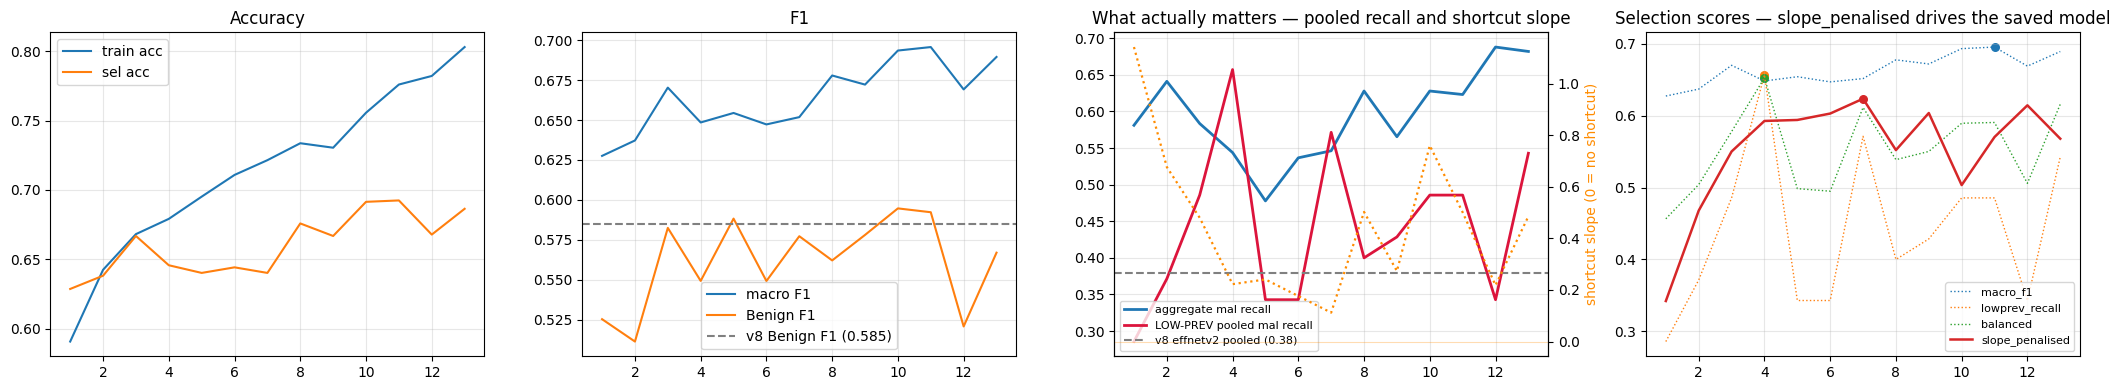

,epoch,tr_acc,loss,accuracy,macro_f1,benign_f1,mal_recall,mcc,macro_auc,stable_sources,worst_src_mal_recall,worst_src_name,shortcut_slope,lowprev_recall,lowprev_n_mal,score_macro_f1,score_lowprev_recall,score_balanced,score_slope_penalised
1,2,0.6425,0.7182,0.6382,0.6372,0.5112,0.6411,0.4511,0.8281,"[cmmd, ddsm]",0.5026,ddsm,0.6767,0.3714,35,0.6372,0.3714,0.5043,0.4680
2,3,0.6682,0.6664,0.6668,0.6703,0.5824,0.5834,0.5035,0.8548,"[cmmd, ddsm]",0.4766,ddsm,0.4800,0.4857,35,0.6703,0.4857,0.5780,0.5503
3,4,0.6792,0.6999,0.6457,0.6485,0.5492,0.5438,0.4744,0.8465,"[cmmd, ddsm]",0.4792,ddsm,0.2225,0.6571,35,0.6485,0.6571,0.6528,0.5929
4,5,0.6952,0.7195,0.6402,0.6544,0.5882,0.4778,0.4787,0.8416,"[cmmd, ddsm]",0.4349,ddsm,0.2408,0.3429,35,0.6544,0.3429,0.4986,0.5942
5,6,0.7109,0.7099,0.6442,0.6473,0.5491,0.5366,0.4741,0.8409,"[cmmd, ddsm]",0.5182,ddsm,0.1764,0.3429,35,0.6473,0.3429,0.4951,0.6032
6,7,0.7215,0.7315,0.6402,0.6518,0.5772,0.5462,0.4627,0.8420,"[cmmd, ddsm]",0.5208,ddsm,0.1121,0.5714,35,0.6518,0.5714,0.6116,0.6238
7,8,0.7337,0.6821,0.6759,0.6779,0.5620,0.6279,0.5118,0.8588,"[cmmd, ddsm]",0.5312,ddsm,0.5025,0.4000,35,0.6779,0.4000,0.5390,0.5523
8,9,0.7305,0.6668,0.6668,0.6722,0.5780,0.5654,0.5051,0.8598,"[cmmd, ddsm]",0.5182,ddsm,0.2733,0.4286,35,0.6722,0.4286,0.5504,0.6039
9,10,0.7557,0.6953,0.6915,0.6935,0.5946,0.6279,0.5376,0.8673,"[cmmd, ddsm]",0.4557,ddsm,0.7599,0.4857,35,0.6935,0.4857,0.5896,0.5036
10,11,0.7760,0.6915,0.6925,0.6957,0.5922,0.6230,0.5388,0.8651,"[cmmd, ddsm]",0.5156,ddsm,0.5009,0.4857,35,0.6957,0.4857,0.5907,0.5705


In [ ]:
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 4, figsize=(21, 4))
ax[0].plot(h.epoch, h.tr_acc, label='train acc'); ax[0].plot(h.epoch, h.accuracy, label='sel acc')
ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(h.epoch, h.macro_f1, label='macro F1'); ax[1].plot(h.epoch, h.benign_f1, label='Benign F1')
ax[1].axhline(0.5851, ls='--', c='grey', label='v8 Benign F1 (0.585)')
ax[1].set_title('F1'); ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].plot(h.epoch, h.mal_recall, label='aggregate mal recall', lw=2)
ax[2].plot(h.epoch, h.lowprev_recall, label='LOW-PREV pooled mal recall', lw=2, color='crimson')
ax[2].axhline(0.38, ls='--', c='grey', label='v8 effnetv2 pooled (0.38)')
ax2b = ax[2].twinx()
ax2b.plot(h.epoch, h.shortcut_slope, lw=1.6, ls=':', color='darkorange', label='shortcut slope')
ax2b.set_ylabel('shortcut slope (0 = no shortcut)', color='darkorange')
ax2b.axhline(0.0, lw=0.8, color='darkorange', alpha=.3)
ax[2].set_title('What actually matters — pooled recall and shortcut slope')
ax[2].legend(loc='lower left', fontsize=8); ax[2].grid(alpha=.3)
for c in TRACKED:
    ax[3].plot(h.epoch, h[f'score_{c}'], label=c, lw=1.8 if c == SELECT_ON else 1.0,
               ls='-' if c == SELECT_ON else ':')
    ax[3].scatter([best_ep[c]], [h.loc[h.epoch == best_ep[c], f'score_{c}'].iloc[0]], s=30)
ax[3].set_title(f'Selection scores — {SELECT_ON} drives the saved model')
ax[3].legend(fontsize=8); ax[3].grid(alpha=.3)
plt.tight_layout(); plt.show()
display(h.round(4).tail(12))

## 9. Test evaluation with per-source breakdown

Loaded epoch 7  (selected on slope_penalised, score 0.6238)
Other checkpoints available from this run:
   macro_f1         epoch 11   best_v9_effnetv2_mt-none_dro_ce_macro_f1.pth
   lowprev_recall   epoch  4   best_v9_effnetv2_mt-none_dro_ce_lowprev_recall.pth
   balanced         epoch  4   best_v9_effnetv2_mt-none_dro_ce_balanced.pth
   slope_penalised  epoch  7   best_v9_effnetv2_mt-none_dro_ce_slope_penalised.pth  <- loaded


eval:   0%|          | 0/89 [00:00<?, ?it/s]


AGGREGATE TEST METRICS
  accuracy     = 0.6760
  macro_f1     = 0.6902
  benign_f1    = 0.6024
  mal_recall   = 0.6019
  mcc          = 0.5111
  macro_auc    = 0.8593

PER-SOURCE BREAKDOWN  (hits/n_mal with exact 95% intervals)


,n,n_mal,prior,hits,mal_recall,ci_lo,ci_hi,pt_per_case,accuracy,benign_f1
source,,,,,,,,,,
cmmd,826,658,0.7966,408,0.6201,0.5817,0.6573,0.15,0.6199,0.3985
ddsm,1528,548,0.3586,324,0.5912,0.5488,0.6327,0.18,0.6433,0.6602
dmid,76,21,0.2763,12,0.5714,0.3402,0.7818,4.76,0.6579,0.4848
inbreast,61,15,0.2459,10,0.6667,0.3838,0.8818,6.67,0.7541,0.8169
kau-bcmd,330,14,0.0424,2,0.1429,0.0178,0.4281,7.14,0.9576,0.8602



SHORTCUT SLOPE                 +0.1104   (0 = recall independent of source)
LOW-PREVALENCE POOLED RECALL   0.4800   (24/50 across dmid, inbreast, kau-bcmd)

Legacy single-source minimum:   0.1429 (kau-bcmd, 14 malignant cases - one case moves it 7.14 points, do not quote it alone)


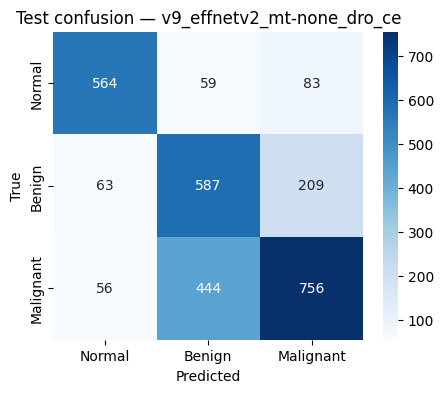

              precision    recall  f1-score   support

      Normal     0.8258    0.7989    0.8121       706
      Benign     0.5385    0.6834    0.6024       859
   Malignant     0.7214    0.6019    0.6562      1256

    accuracy                         0.6760      2821
   macro avg     0.6952    0.6947    0.6902      2821
weighted avg     0.6918    0.6760    0.6788      2821



In [ ]:
ck = torch.load(CKPT, map_location=device, weights_only=False)
model.load_state_dict(ck['model_state_dict'])
print(f'Loaded epoch {ck["epoch"]}  (selected on {ck.get("criterion", SELECT_ON)}, '
      f'score {ck.get("score", float("nan")):.4f})')
print('Other checkpoints available from this run:')
for c in TRACKED:
    mark = '  <- loaded' if c == SELECT_ON else ''
    print(f'   {c:16s} epoch {best_ep[c]:>2}   {os.path.basename(CKPT_OF[c])}{mark}')

tm, test_logits, test_y, test_probs = evaluate(model, test_loader, criterion, test_src)
yt = test_y.numpy(); pred = test_logits.argmax(1).numpy()

print('\nAGGREGATE TEST METRICS')
for k in ['accuracy','macro_f1','benign_f1','mal_recall','mcc','macro_auc']:
    print(f'  {k:12s} = {tm[k]:.4f}')

per_src = per_source_stats(yt, pred, test_src)
extra = []
for si, sname in enumerate(SOURCE_NAMES):
    mk = test_src == si
    if mk.sum() == 0 or sname not in per_src.index: continue
    y_s, p_s = yt[mk], pred[mk]
    f1s = f1_score(y_s, p_s, average=None, labels=[0,1,2], zero_division=0)
    extra.append({'source': sname,
                  'accuracy': round(accuracy_score(y_s, p_s), 4),
                  'benign_f1': round(f1s[1], 4)})
per_src = per_src.join(pd.DataFrame(extra).set_index('source'))
per_src['mal_recall'] = per_src['mal_recall'].round(4)

print('\nPER-SOURCE BREAKDOWN  (hits/n_mal with exact 95% intervals)')
display(per_src)

TEST_SLOPE   = shortcut_slope(per_src)
TEST_LOWPREV = lowprev_recall(per_src)
lp = per_src[per_src['prior'] < LOWPREV_MAX_PRIOR]
print(f"\nSHORTCUT SLOPE                 {TEST_SLOPE:+.4f}   (0 = recall independent of source)")
print(f"LOW-PREVALENCE POOLED RECALL   {TEST_LOWPREV:.4f}   "
      f"({int(lp['hits'].sum())}/{int(lp['n_mal'].sum())} across {', '.join(lp.index)})")
print(f"\nLegacy single-source minimum:   {per_src['mal_recall'].min():.4f} "
      f"({per_src['mal_recall'].idxmin()}, {int(per_src.loc[per_src['mal_recall'].idxmin(),'n_mal'])} "
      f"malignant cases - one case moves it "
      f"{per_src.loc[per_src['mal_recall'].idxmin(),'pt_per_case']:.2f} points, do not quote it alone)")

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(yt, pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Test confusion — {TAG}')
plt.show()
print(classification_report(yt, pred, target_names=CLASS_NAMES, digits=4))

## 10. Did the auxiliary heads actually learn anything?

If a head cannot predict its own task above chance, it contributed no gradient signal worth
having and its weight should go to zero rather than being left in as decoration.

In [ ]:
@torch.no_grad()
def aux_report(m, loader):
    if not AUX_SPEC:
        print('No auxiliary heads enabled in this run.'); return
    m.eval()
    store = {k: {'p': [], 't': []} for k, _ in AUX_SPEC}
    for batch in tqdm(loader, leave=False, desc='aux'):
        x, a, v, l, s, y = [t.to(device, non_blocking=True) for t in batch[:6]]
        with torch.amp.autocast(device_type='cuda'):
            out = m(x, a, v, l, s)
        for k, _ in AUX_SPEC:
            tgt = batch[AUX_TARGET_POS[k]]
            store[k]['p'].append(out[k].float().cpu().argmax(1))
            store[k]['t'].append(tgt)
    for k, _ in AUX_SPEC:
        p = torch.cat(store[k]['p']).numpy(); t = torch.cat(store[k]['t']).numpy()
        mk = t != IGNORE
        if mk.sum() == 0:
            print(f'{k}: no labelled rows in this split'); continue
        acc = accuracy_score(t[mk], p[mk])
        maj = pd.Series(t[mk]).value_counts(normalize=True).max()
        print(f'{k:4s}  n={mk.sum():5d}  accuracy={acc:.4f}  majority-class={maj:.4f}  '
              f'{"LEARNED" if acc > maj + 0.02 else "NOT ABOVE BASELINE"}')

aux_report(model, test_loader)

No auxiliary heads enabled in this run.


## 11. Comparison — every model on the corrected metrics

Aggregate numbers plus the two shortcut metrics recomputed for every model in the project.
The single-source column is shown with its case count so it can never be read as a headline
again.

,accuracy,macro_f1,benign_f1,mal_recall,mcc,macro_auc,shortcut_slope,lowprev_recall
model,,,,,,,,
S3 ensemble (source input),0.7373,0.7415,0.6340,0.7811,0.5908,0.8918,0.813,0.34
v8 resnet101 (no source),0.6930,0.7033,0.5942,0.6728,0.5286,0.8696,0.440,0.44
v8 effnetv2 (no source),0.7097,0.7152,0.5851,0.7229,0.5508,0.8675,0.650,0.38
v9 multi-task (den+abn),0.7168,0.7124,0.5754,0.7452,0.5652,0.8760,0.815,0.46
v10 THIS RUN (v9_effnetv2_mt-none_dro_ce),0.6760,0.6902,0.6024,0.6019,0.5111,0.8593,0.110,0.48


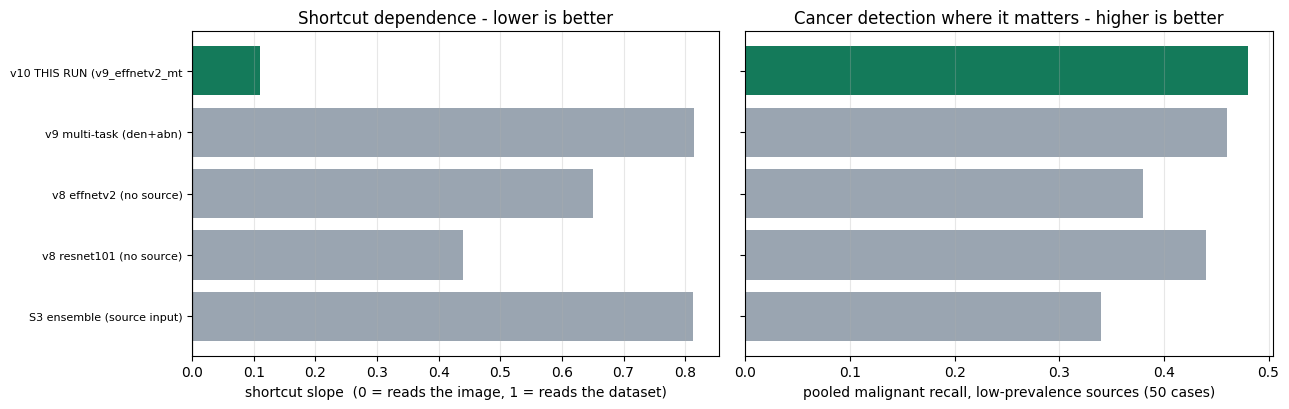

VERDICT  (against v8 effnetv2 (no source))
  shortcut slope        +0.650 -> +0.110   (-0.539)
  low-prev pooled recall 0.3800 -> 0.4800   (+0.1000)
  macro F1               0.7152 -> 0.6902   (-0.0250)

  -> the shortcut weakened without costing cancer detection. Real progress.

  Reminder: 50 malignant cases underlie the pooled figure, so treat differences
  under about 0.06 as noise. RSNA is where this gets settled properly.


In [ ]:
HIST = {
 'S3 ensemble (source input)': {
    'agg': {'accuracy':0.7373,'macro_f1':0.7415,'benign_f1':0.6340,
            'mal_recall':0.7811,'mcc':0.5908,'macro_auc':0.8918},
    'rec': [0.9514,0.6168,0.4286,0.4000,0.1429]},
 'v8 resnet101 (no source)': {
    'agg': {'accuracy':0.6930,'macro_f1':0.7033,'benign_f1':0.5942,
            'mal_recall':0.6728,'mcc':0.5286,'macro_auc':0.8696},
    'rec': [0.7660,0.5821,0.4762,0.4000,0.4286]},
 'v8 effnetv2 (no source)': {
    'agg': {'accuracy':0.7097,'macro_f1':0.7152,'benign_f1':0.5851,
            'mal_recall':0.7229,'mcc':0.5508,'macro_auc':0.8675},
    'rec': [0.8587,0.5912,0.3810,0.6000,0.1429]},
 'v9 multi-task (den+abn)': {
    'agg': {'accuracy':0.7168,'macro_f1':0.7124,'benign_f1':0.5754,
            'mal_recall':0.7452,'mcc':0.5652,'macro_auc':0.8760},
    'rec': [0.9179,0.5639,0.7143,0.4667,0.0714]},
}
ORDER      = ['cmmd','ddsm','dmid','inbreast','kau-bcmd']
TEST_PRIOR = np.array([0.797,0.359,0.276,0.246,0.042])
TEST_NMAL  = np.array([658,  549,  21,   15,   14])

def hist_metrics(rec):
    rec = np.array(rec, float)
    sl  = float(np.polyfit(TEST_PRIOR, rec, 1, w=np.sqrt(TEST_NMAL))[0])
    lowm = TEST_PRIOR < LOWPREV_MAX_PRIOR
    pooled = float((rec[lowm]*TEST_NMAL[lowm]).sum() / TEST_NMAL[lowm].sum())
    return sl, pooled

BASE_NAME = 'v8 effnetv2 (no source)' if ARCH == 'effnetv2' else 'v8 resnet101 (no source)'
rows = []
for name, d in HIST.items():
    sl, pooled = hist_metrics(d['rec'])
    rows.append({'model': name, **d['agg'], 'shortcut_slope': round(sl, 3),
                 'lowprev_recall': round(pooled, 4)})
rows.append({'model': f'v10 THIS RUN ({TAG})',
             **{k: round(tm[k], 4) for k in ['accuracy','macro_f1','benign_f1',
                                             'mal_recall','mcc','macro_auc']},
             'shortcut_slope': round(TEST_SLOPE, 3),
             'lowprev_recall': round(TEST_LOWPREV, 4)})
cmp_df = pd.DataFrame(rows).set_index('model')
display(cmp_df)

base_sl, base_lp = hist_metrics(HIST[BASE_NAME]['rec'])
best_sl_name = cmp_df['shortcut_slope'].abs().idxmin()

fig, axx = plt.subplots(1, 2, figsize=(13, 4.2))
cols = ['#9AA5B1' if m != f'v10 THIS RUN ({TAG})' else '#147A5A' for m in cmp_df.index]
axx[0].barh(range(len(cmp_df)), cmp_df['shortcut_slope'], color=cols)
axx[0].set_yticks(range(len(cmp_df)))
axx[0].set_yticklabels([m[:28] for m in cmp_df.index], fontsize=8)
axx[0].axvline(0, color='k', lw=.8)
axx[0].set_xlabel('shortcut slope  (0 = reads the image, 1 = reads the dataset)')
axx[0].set_title('Shortcut dependence - lower is better'); axx[0].grid(alpha=.3, axis='x')
axx[1].barh(range(len(cmp_df)), cmp_df['lowprev_recall'], color=cols)
axx[1].set_yticks(range(len(cmp_df))); axx[1].set_yticklabels([])
axx[1].set_xlabel('pooled malignant recall, low-prevalence sources (50 cases)')
axx[1].set_title('Cancer detection where it matters - higher is better')
axx[1].grid(alpha=.3, axis='x')
plt.tight_layout(); plt.show()

print('VERDICT  (against ' + BASE_NAME + ')')
print(f'  shortcut slope        {base_sl:+.3f} -> {TEST_SLOPE:+.3f}   ({TEST_SLOPE-base_sl:+.3f})')
print(f'  low-prev pooled recall {base_lp:.4f} -> {TEST_LOWPREV:.4f}   ({TEST_LOWPREV-base_lp:+.4f})')
print(f'  macro F1               {HIST[BASE_NAME]["agg"]["macro_f1"]:.4f} -> {tm["macro_f1"]:.4f}   '
      f'({tm["macro_f1"]-HIST[BASE_NAME]["agg"]["macro_f1"]:+.4f})')
print()
d_sl = TEST_SLOPE - base_sl
d_lp = TEST_LOWPREV - base_lp
if d_sl < -0.10 and d_lp > -0.02:
    print('  -> the shortcut weakened without costing cancer detection. Real progress.')
elif d_sl < -0.10:
    print('  -> shortcut weakened but pooled recall fell. Check whether the model simply')
    print('     predicts Malignant less often everywhere.')
elif abs(d_sl) <= 0.10:
    print('  -> no meaningful change in shortcut dependence.')
    print(f'     Standing best remains {best_sl_name} at slope {cmp_df["shortcut_slope"].abs().min():+.3f}.')
else:
    print('  -> shortcut got STRONGER. This intervention is not the answer.')
print()
print('  Reminder: 50 malignant cases underlie the pooled figure, so treat differences')
print('  under about 0.06 as noise. RSNA is where this gets settled properly.')

## 12. Calibration and save

In [ ]:
def ece(probs, labels, n_bins=15):
    conf, pr = probs.max(1), probs.argmax(1)
    acc = (pr == labels).astype(np.float32)
    bins = np.linspace(0, 1, n_bins+1); e = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 0: e += m.mean()*abs(acc[m].mean()-conf[m].mean())
    return float(e)

sm2, sel_logits, sel_y, _ = evaluate(model, sel_loader, criterion, sel_src)
ece_before = ece(F.softmax(sel_logits, 1).numpy(), sel_y.numpy())

init_T = 1.0/LDAM_S if LOSS_TYPE == 'lmf' else 1.0
log_T = nn.Parameter(torch.log(torch.tensor([init_T], device=device, dtype=torch.float32)))
optT = torch.optim.LBFGS([log_T], lr=0.1, max_iter=500,
                         tolerance_grad=1e-9, tolerance_change=1e-11)
vl, vy = sel_logits.to(device), sel_y.to(device)
def closure():
    optT.zero_grad(); loss = F.cross_entropy(vl/torch.exp(log_T), vy); loss.backward(); return loss
optT.step(closure)
T = float(torch.exp(log_T).detach().cpu().item())
ece_after = ece(F.softmax(test_logits/T, 1).numpy(), yt)
print(f'Temperature T = {T:.5f}   ECE {ece_before:.4f} -> {ece_after:.4f}')

bundle = {'model_state_dict': model.state_dict(), 'temperature': T,
          'class_names': CLASS_NAMES, 'input_size': IMG_SIZE,
          'mean': NORM_MEAN, 'std': NORM_STD,
          'test_metrics': {k: v for k, v in tm.items() if k != 'per_source_mal_recall'},
          'per_source': per_src.reset_index().to_dict('records'),
          'selected_on': SELECT_ON, 'selected_epoch': int(ck['epoch']),
          'all_criteria_epochs': {c: best_ep[c] for c in TRACKED},
          'shortcut_slope': TEST_SLOPE, 'lowprev_recall': TEST_LOWPREV,
          'lowprev_max_prior': LOWPREV_MAX_PRIOR,
          'ece_before': ece_before, 'ece_after': ece_after,
          'uses_source_embedding': USE_SOURCE, 'n_meta_embeddings': N_META,
          'aux_heads': {'density': AUX_DENSITY, 'abnormality': AUX_ABNORM, 'birads': AUX_BIRADS},
          'aux_weights': {'density': W_DENSITY, 'abnormality': W_ABNORM, 'birads': W_BIRADS},
          'balance_aux_by_source': BALANCE_AUX_BY_SOURCE,
          'group_dro': GROUP_DRO, 'dro_eta': DRO_ETA,
          'architecture': ('ResNet-101 + metadata' if ARCH == 'resnet101'
                           else 'EfficientNetV2-S + CBAM + metadata'),
          'loss': LOSS_TYPE, 'select_on': SELECT_ON,
          'split': 'frozen_split.json (train+old_val / selection / test)',
          'sprint': f'Sprint 4 / {TAG}'}
path = os.path.join(CHECKPT_DIR, f'final_{TAG}_bundle.pth')
torch.save(bundle, path)
per_src.to_csv(os.path.join(CHECKPT_DIR, f'per_source_{TAG}.csv'))
print('Saved:', path)

eval:   0%|          | 0/63 [00:00<?, ?it/s]

Temperature T = 1.66105   ECE 0.1212 -> 0.0284
Saved: /content/drive/MyDrive/momobench-dataset/checkpoints_v9_effnetv2_mt-none_dro_ce/final_v9_effnetv2_mt-none_dro_ce_bundle.pth


## How to read the result

**The bar is v8 ResNet-101 at case-weighted slope 0.440.** Everything else built so far sits
at 0.650 (v8 effnetv2), 0.813 (S3 ensemble), 0.815 (v9), 1.045 (v10).

| Outcome | Reading | Next |
|---|---|---|
| slope below 0.44, pooled recall holds | DRO beat the best model in the project. The objective was the right lever. | Ensemble with v8 ResNet-101, then RSNA |
| slope 0.44–0.65, pooled recall holds | Real improvement over the matched EfficientNetV2 baseline, short of the ResNet | Try `DRO_ETA = 0.0003`, or `AUX_DENSITY = True` for the Benign gain |
| slope unchanged from 0.650 | Neither representation nor objective interventions work on this data | Stop optimising internally; go to RSNA and report the shortcut honestly |
| slope drops, pooled recall drops too | Check aggregate malignant recall — the model may just be predicting Malignant less often | Not a win |

**Check `q_max` first.** If it climbed past 0.6 the model spent the run training on one
group and the result says nothing about DRO in general, only about that eta.

**Statistical floor, unchanged.** 50 malignant cases underlie the pooled figure and v7 showed
about 3 points of run-to-run variance between identical configurations. Differences under
roughly 0.06 pooled, or 0.10 slope, are noise.

## Four checkpoints, one run

`SAVE_ALL_CRITERIA` writes the best epoch under each rule:

```
best_<TAG>_macro_f1.pth          aggregate-optimal
best_<TAG>_lowprev_recall.pth    detection on screening-like sources
best_<TAG>_balanced.pth          the v10 default
best_<TAG>_slope_penalised.pth   loaded for evaluation
```

Section 9 prints the epoch each one landed on. If they disagree sharply — as they did in v10,
epoch 4 against epoch 9 — that disagreement is itself the finding: aggregate quality and
provenance-independence are trading off against each other, and you now have both models on
disk to ensemble or compare rather than one.

## Runs to queue

1. **As configured** — DRO alone, no auxiliary heads. The clean test of the objective.
2. **`AUX_DENSITY = True`, DRO on** — only if run 1 improves the slope. Density bought
   +2.1 Benign F1 in v10; worth recovering if DRO holds the slope down.
3. **`ARCH = 'resnet101'`, DRO on** — the current best model on slope, plus the objective fix.
   Slower at 512px, but ResNet-101 is the architecture that has resisted the shortcut best.

## Then stop

Three interventions have now been tried against this shortcut: deleting the input (v8, worked
on one architecture of two), auxiliary supervision (v9/v10, made it worse both times), and
worst-group optimisation (this notebook). Whatever this returns, the next step is RSNA —
thousands of cancers at roughly 2% prevalence, which is the regime every one of these
experiments has been trying to approximate with 50 cases.